# OpenScope Ophys QC Validation

| Stage | Scope | Goal |
|-------|-------|------|
| **1** | Single session | Inspect metrics and establish reference distributions |
| **2** | Multiple sessions | Scale to a sample of the full dataset |

**Prerequisites:**
```bash
pip install -r requirements_mesoscope_qc.txt
```


## Shared imports

In [ ]:
from __future__ import annotations
import importlib
import json
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import sys
sys.path.insert(0, "../src")
import mesoscope_qc_pipeline as qc
import session_loader as sl

qc = importlib.reload(qc)
sl = importlib.reload(sl)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 100)

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline loaded from:", Path(qc.__file__).resolve())


Pipeline loaded from: C:\Users\nicho\Documents\openscope\OpenScope_Ophys_QC\src\mesoscope_qc_pipeline.py


---
# Stage 1 — Single Session

**Goal:** Open one well-characterized session, inspect every QC metric in detail,
and establish reference distributions that define "good" data.


### 1.1 — Configuration

In [21]:
SESSION_SOURCE = (
    "s3://aind-open-data/"
    "multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22"
)
MAX_FRAMES = 10_000   # set to None for full session (slower)
PLANES     = "all"    # or e.g. ["VISp_0", "VISl_4"]

OUT_DIR = Path("outputs/stage1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Session  :", SESSION_SOURCE)
print("Max frames:", MAX_FRAMES)


Session  : s3://aind-open-data/multiplane-ophys_837568_2026-03-05_14-14-51_processed_2026-03-06_11-31-22
Max frames: 10000


### 1.2 — Load session

In [22]:
session    = sl.load_session(SESSION_SOURCE)
nwb        = session["nwb"]
plane_meta = session["plane_meta"]
planes     = session["planes"]
meta       = session["meta"]

(OUT_DIR / "session_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

subj = meta.get("subject", {})
display(pd.DataFrame([{
    "session_id" : meta.get("session_id"),
    "subject_id" : subj.get("subject_id"),
    "genotype"   : subj.get("genotype"),
    "sex"        : subj.get("sex"),
    "age"        : subj.get("age"),
    "n_planes"   : len(meta.get("imaging_planes", [])),
}]))
display(plane_meta)


,session_id,subject_id,genotype,sex,age,n_planes
0,multiplane-ophys_837568_2026-03-05_14-14-51,837568,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,M,P121D,8


,plane,structure,depth_um,location,imaging_rate_hz,excitation_lambda_nm,indicator,device
0,VISl_4,VISl,173.0,Structure: VISl Depth: 173,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
1,VISl_5,VISl,297.0,Structure: VISl Depth: 297,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
2,VISl_6,VISl,57.0,Structure: VISl Depth: 57,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
3,VISl_7,VISl,384.0,Structure: VISl Depth: 384,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
4,VISp_0,VISp,184.0,Structure: VISp Depth: 184,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
5,VISp_1,VISp,271.0,Structure: VISp Depth: 271,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
6,VISp_2,VISp,60.0,Structure: VISp Depth: 60,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1
7,VISp_3,VISp,380.0,Structure: VISp Depth: 380,9.48,920.0,Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt,MESO.1


### 1.3 — Run per-ROI QC

In [23]:
planes_to_run = planes if PLANES == "all" else list(PLANES)

roi_dfs = []
for pname in planes_to_run:
    print(f"  Analyzing {pname} …")
    df = qc.analyze_plane(nwb, pname, max_frames=MAX_FRAMES)
    roi_dfs.append(df)

roi_qc        = pd.concat(roi_dfs, ignore_index=True).merge(plane_meta, on="plane", how="left")
plane_summary = qc.summarize_planes(roi_qc, plane_meta)

roi_qc.to_csv(OUT_DIR / "roi_qc.csv",         index=False)
plane_summary.to_csv(OUT_DIR / "plane_qc.csv", index=False)

display(plane_summary[["plane", "structure", "depth_um", "n_rois", "n_soma",
                        "dff_std_median", "event_rate_hz_median", "sampling_rate_hz"]])


  Analyzing VISl_4 …
  Analyzing VISl_5 …
  Analyzing VISl_6 …
  Analyzing VISl_7 …
  Analyzing VISp_0 …
  Analyzing VISp_1 …
  Analyzing VISp_2 …
  Analyzing VISp_3 …


,plane,structure,depth_um,n_rois,n_soma,dff_std_median,event_rate_hz_median,sampling_rate_hz
0,VISl_4,VISl,173.0,353,335,0.198981,0.299570,9.478673
1,VISl_5,VISl,297.0,249,240,0.266576,0.818129,9.478673
2,VISl_6,VISl,57.0,130,121,0.093359,0.164479,9.478673
3,VISl_7,VISl,384.0,248,232,0.164893,0.525195,9.478673
4,VISp_0,VISp,184.0,386,361,0.184672,0.282980,9.478673
5,VISp_1,VISp,271.0,458,397,0.237930,0.428025,9.478673
6,VISp_2,VISp,60.0,130,119,0.100048,0.229417,9.478673
7,VISp_3,VISp,380.0,263,250,0.145149,0.514767,9.478673


### 1.4 — Reference distributions

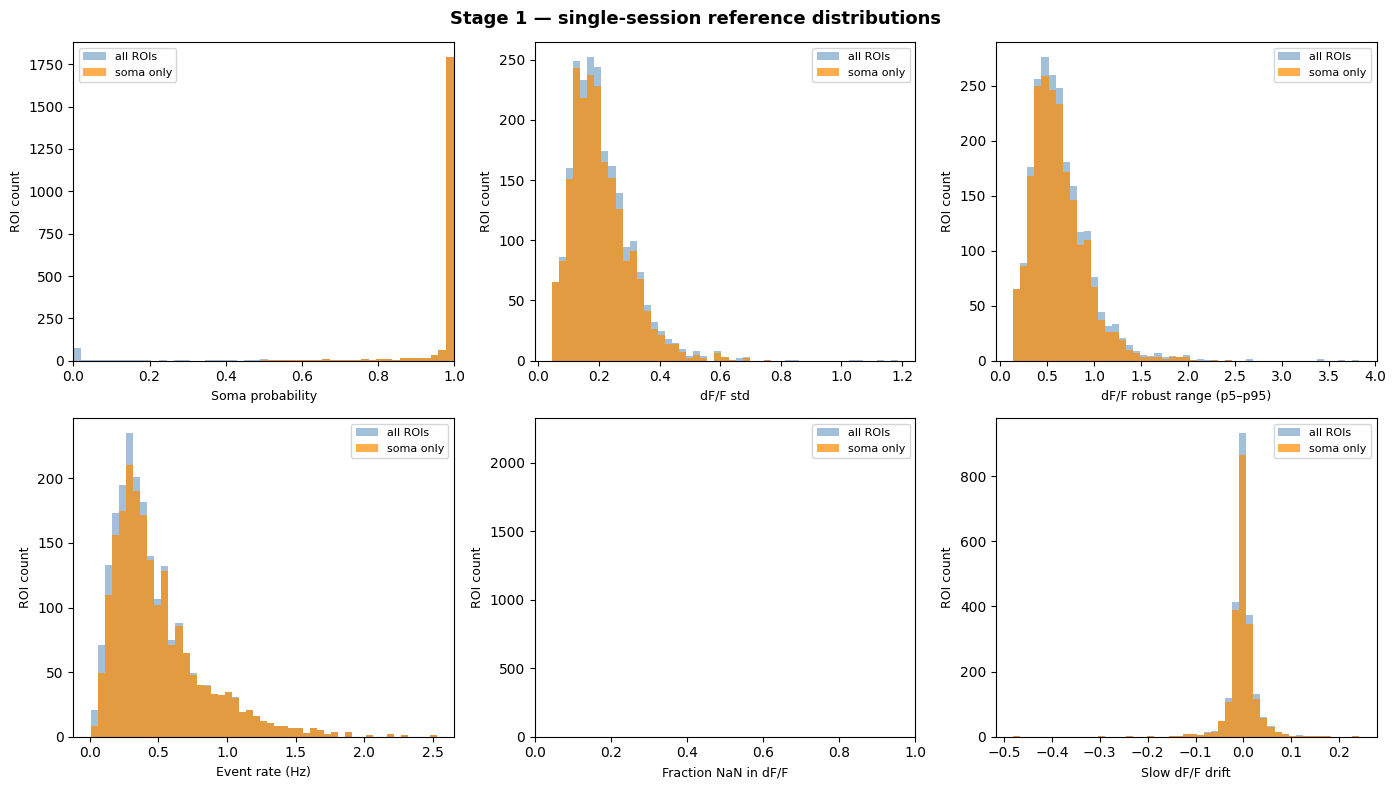

In [24]:
fig = sl.plot_reference_distributions(
    roi_qc,
    title="Stage 1 — single-session reference distributions",
    save_path=FIGURES_DIR / "stage1_reference_distributions.png",
)
plt.show()


### 1.5 — Per-plane summary

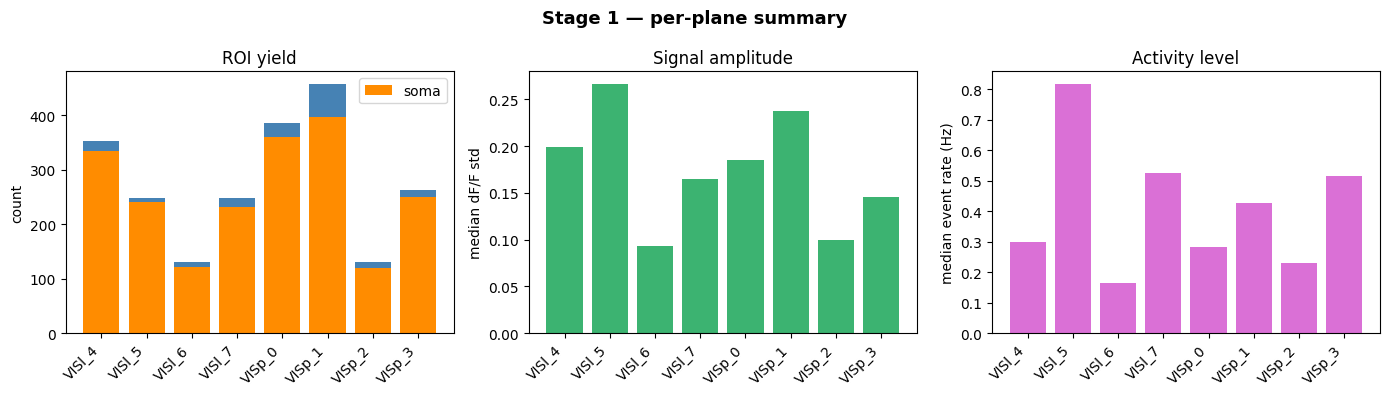

In [25]:
fig = sl.plot_plane_summary(
    plane_summary,
    title="Stage 1 — per-plane summary",
    save_path=FIGURES_DIR / "stage1_plane_summary.png",
)
plt.show()

sl.close_session(session)


---
# Stage 2 — Multiple Sessions

**Goal:** Load a sample of sessions from the full dataset.


### 2.1 — Discover sessions

In [26]:
all_paths = sl.discover_sessions()
print(f"Found {len(all_paths)} sessions")
for p in all_paths[:5]:
    print(" ", p)
if len(all_paths) > 5:
    print(f"  … and {len(all_paths) - 5} more")


Found 364 sessions
  s3://aind-open-data/multiplane-ophys_775682_2025-03-03_09-39-23_processed_2025-03-04_17-19-32
  s3://aind-open-data/multiplane-ophys_779190_2025-03-03_13-36-14_processed_2025-03-04_16-38-10
  s3://aind-open-data/multiplane-ophys_800792_2025-11-06_11-00-52_processed_2025-11-07_13-53-38
  s3://aind-open-data/multiplane-ophys_800792_2025-11-07_11-04-07_processed_2025-11-08_12-40-04
  s3://aind-open-data/multiplane-ophys_800792_2025-11-11_09-26-07_processed_2025-11-12_12-35-00
  … and 359 more


### 2.2 — Load sample

In [ ]:
SAMPLE_SIZE = 3
RANDOM_SEED = 42

OUT_DIR2 = Path("outputs/stage2")
OUT_DIR2.mkdir(parents=True, exist_ok=True)

sessions = sl.load_sessions(all_paths, n=SAMPLE_SIZE, seed=RANDOM_SEED)


Loading multiplane-ophys_843168_2026-04-28_09-46-15_processed_2026-04-29_11-02-00 ... 

### 2.3 — Inspect loaded sessions

In [ ]:
rows = []
for s in sessions:
    subj = s["meta"].get("subject", {})
    rows.append({
        "session_id": s["meta"].get("session_id"),
        "subject_id": subj.get("subject_id"),
        "genotype"  : subj.get("genotype"),
        "n_planes"  : len(s["planes"]),
    })

display(pd.DataFrame(rows))


### 2.4 — Close sessions

In [ ]:
sl.close_sessions(sessions)
